In [1]:
# load all files in logs
import os
import time
import numpy as np
import pandas as pd
import pickle as pkl
import seaborn as sns
import matplotlib.pyplot as plt

algos_color_palette = {
                       'SCM': sns.color_palette('tab10')[0],
                       'ICSCM': sns.color_palette('tab10')[3],
                       }

datasets_selection = [
    'college_scorecard_envdefinition_binaryood_quantized_50',
    'diabetes_readmission_envdefinition_binaryood_quantized_50',
    'meps_envdefinition_binaryood_quantized_50',
    'acsfoodstamps_envdefinition_binaryood_quantized_50',
    'acsincome_envdefinition_binaryood_quantized_50',
    'assistments_envdefinition_binaryood_quantized_50',
]

# sort alphabetically
datasets_selection = sorted(datasets_selection)

In [2]:
datasets_logs_count = {}
for file in os.listdir('logs'):
    dataset_name = file.split('dataset_')[1].split('_algo')[0]
    if dataset_name not in datasets_logs_count:
        datasets_logs_count[dataset_name] = 0
    datasets_logs_count[dataset_name] += 1

# sort by number of logs
datasets_logs_count = {k: v for k, v in sorted(datasets_logs_count.items(), key=lambda item: item[1], reverse=True)}
for d in datasets_logs_count:
    print(f'{d:65} {datasets_logs_count[d]} logs')

college_scorecard_envdefinition_binaryood_quantized_50            40 logs
meps_envdefinition_binaryood_quantized_50                         40 logs
assistments_envdefinition_binaryood_quantized_50                  40 logs
acsincome_envdefinition_binaryood_quantized_50                    40 logs
acsfoodstamps_envdefinition_binaryood_quantized_50                40 logs
diabetes_readmission_envdefinition_binaryood_quantized_50         40 logs


In [3]:
featuresused_df_dict = {}
causalfeatures_dict = {}
for dataset_name in datasets_logs_count:
    short_name = dataset_name.split('_envdefinition')[0]
    featuresused_df_dict[dataset_name] = {}
    causalfeatures_file = f'datasets/{short_name}_causal_features.pkl'
    try:
        with open(causalfeatures_file, 'rb') as f:
            causalfeatures_dict[dataset_name] = pkl.load(f)
    except:
        print('no causal features for', dataset_name)
        pass
scores_df = pd.DataFrame(columns=['dataset', 'algo', 'split_id', 'metric', 'type', 'score'])

In [4]:
def get_rank_to_causalcount_dict(model, algo, features_names, causal_variables):
    result = {}
    if 'SCM' in algo:
        if hasattr(model, 'rule_importances'):
            causal_count = 0
            rank = 0
            for i in range(len(model.rule_importances)):
                if model.rule_importances[i] > 0:
                    feat_id = model.model_.rules[i].feature_idx
                    feat_name = features_names[feat_id]
                    rank += 1
                    if feat_name in causal_variables:
                        causal_count += 1
                    result[rank] = causal_count
    elif algo in ['DT']:
        tree = model.tree_
        node_depth = np.zeros(tree.node_count, dtype=int)
        t0 = time.time()
        for i in range(tree.node_count):
            if tree.children_left[i] != -1 or tree.children_right[i] != -1:
                if tree.children_left[i] != -1:
                    node_depth[tree.children_left[i]] = node_depth[i] + 1
                if tree.children_right[i] != -1:
                    node_depth[tree.children_right[i]] = node_depth[i] + 1
        t1 = time.time()
        print('time to compute node_depth:', t1-t0, 's')
        nodeid_to_feature_dict = {node_id: model.tree_.feature[node_id] for node_id in range(len(model.tree_.feature))}
        rank = 1
        causal_count = 0
        for depth in range(5):
            nodes_idx_at_this_depth = [i for i in range(len(node_depth)) if node_depth[i] == depth]
            if len(nodes_idx_at_this_depth) == 0:
                print('depth', depth, 'has the same number of nodes as depth', depth-1)
                break
            for node_id in nodes_idx_at_this_depth:
                feat_id = nodeid_to_feature_dict[node_id]
                feat_name = features_names[feat_id]
                if feat_name in causal_variables:
                    causal_count += 1
            result[rank] = causal_count
            rank += 2**depth
    elif algo in ['RF']:
        features_importances = model.feature_importances_
        # keep only the ones that are not 0
        f_to_importance = {features_names[i]: features_importances[i] for i in range(len(features_importances)) if features_importances[i] > 0}
        # sort by importance
        f_to_importance = {k: v for k, v in sorted(f_to_importance.items(), key=lambda item: item[1], reverse=True)}
        causal_count = 0
        rank = 0
        for f in f_to_importance:
            rank += 1
            if f in causal_variables:
                causal_count += 1
            result[rank] = causal_count
    elif algo == 'LogisticRegression':
        pass
    elif algo == 'XGBoost':
        pass
    elif algo == 'ICP':
        pass
    else:
        print('algo not recognized')
        print(model)
    #print(result)
    return result

In [5]:
dict_of_featuresranksdfs = {}
all_features_dict = {}

for file in os.listdir('logs'):
    dataset_name = file.split('_algo')[0].split('dataset_')[1]
    split_id = int(file.split('split_')[1].split('.pkl')[0])
    algo = file.split('algo_')[1].split('_split')[0]
    log_filepath = os.path.join('logs', file)
    if algo not in algos_color_palette:
        print('algo not in selection:', algo)
        continue
    with open(log_filepath, 'rb') as f:
        try:
            res = pkl.load(f)
        except Exception as e:
            print('error:', e)
            print('file:', file)
            continue
    if 'model' not in res:
        print('rm logs/{}'.format(file))
        continue
    model = res['model']
    features_names = res['features_names']
    scores_dict = res['scores_dict']
    if dataset_name not in all_features_dict:
        all_features_dict[dataset_name] = features_names
    if dataset_name not in causalfeatures_dict:
        print(dataset_name, 'have no causal features defined')
        continue
    causal_variables = causalfeatures_dict[dataset_name]
    if dataset_name not in dict_of_featuresranksdfs:
        dict_of_featuresranksdfs[dataset_name] = {}
    if algo not in dict_of_featuresranksdfs[dataset_name]:
        dict_of_featuresranksdfs[dataset_name][algo] = {}
    rank_to_causalcount_dict = get_rank_to_causalcount_dict(model, algo, features_names, causal_variables)
    dict_of_featuresranksdfs[dataset_name][algo][split_id] = rank_to_causalcount_dict

In [6]:
# table with datasets on index, algos on columns, values are the number of splits
datasets_algos_splits = pd.DataFrame(columns=list(algos_color_palette.keys()), index=datasets_logs_count.keys())
for dataset_name in datasets_logs_count:
    for algo in list(algos_color_palette.keys()):
        if dataset_name in dict_of_featuresranksdfs:
            if algo in dict_of_featuresranksdfs[dataset_name]:
                datasets_algos_splits.loc[dataset_name, algo] = len(dict_of_featuresranksdfs[dataset_name][algo])
            else:
                datasets_algos_splits.loc[dataset_name, algo] = ''
        else:
            datasets_algos_splits.loc[dataset_name, algo] = ''
datasets_algos_splits

,SCM,ICSCM
college_scorecard_envdefinition_binaryood_quantized_50,20,20
meps_envdefinition_binaryood_quantized_50,20,20
assistments_envdefinition_binaryood_quantized_50,20,20
acsincome_envdefinition_binaryood_quantized_50,20,20
acsfoodstamps_envdefinition_binaryood_quantized_50,20,20
diabetes_readmission_envdefinition_binaryood_quantized_50,20,20


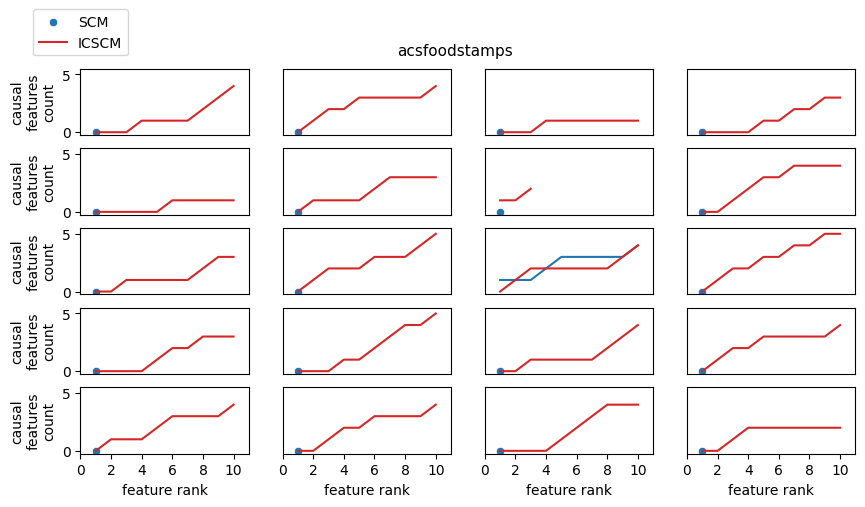

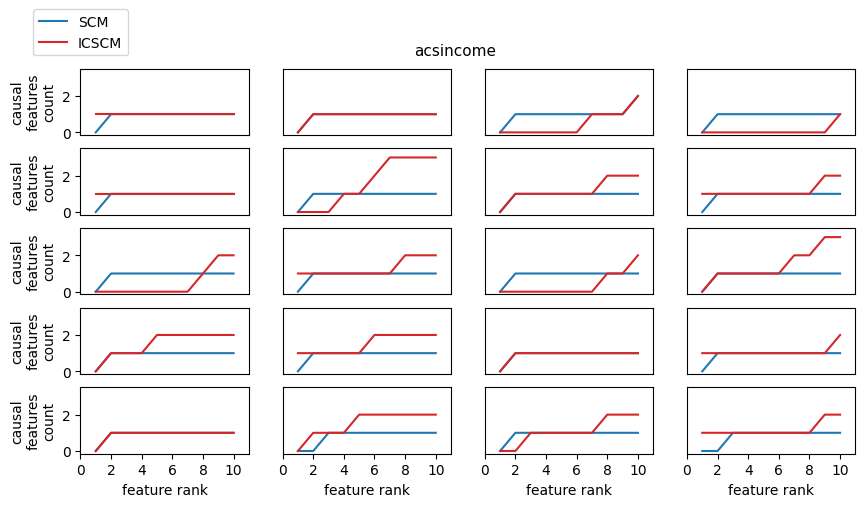

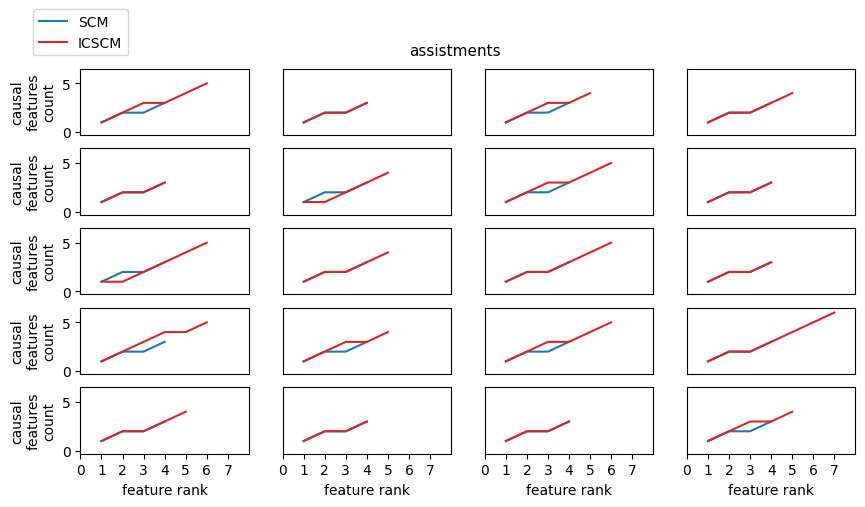

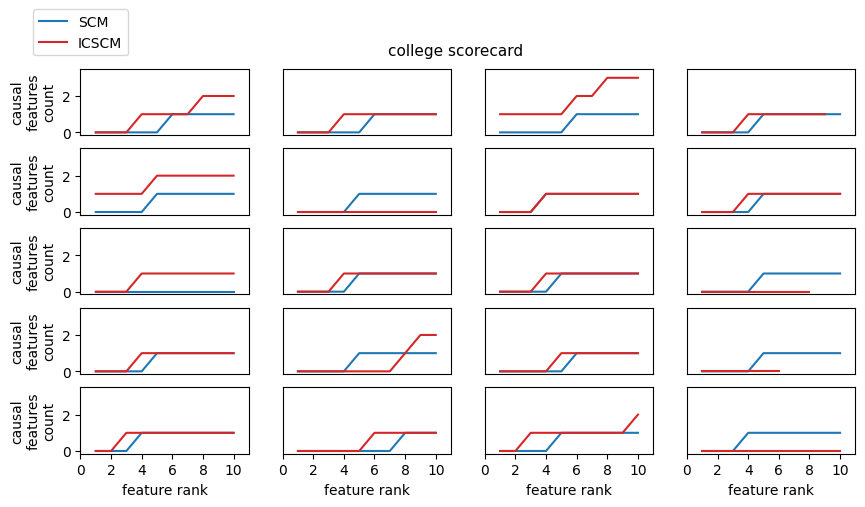

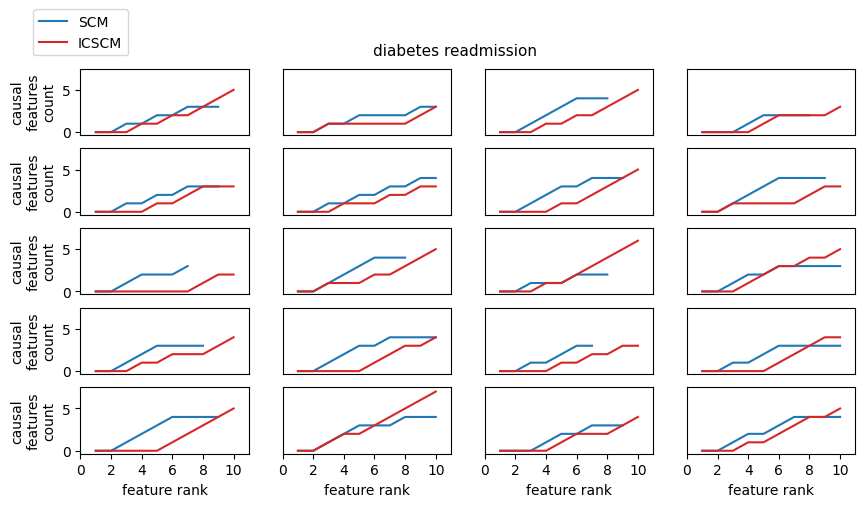

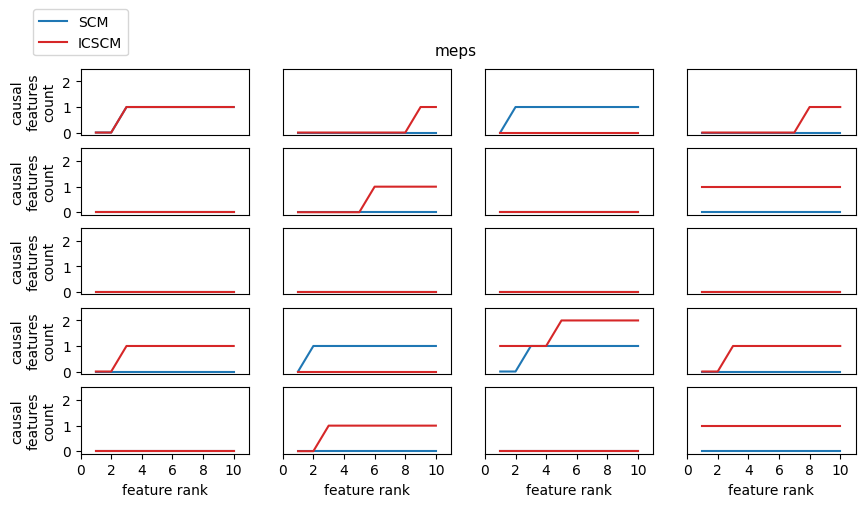

In [7]:
fixed_max_rules = 12

# figure, one per dataset, 20 subplots on 2 columns
for dataset_name in datasets_selection:
    if dataset_name not in dict_of_featuresranksdfs:
            continue
    saving_dataset_name = dataset_name.split('_envdefinition')[0]
    fig, axs = plt.subplots(5, 4, figsize=(10, 5))
    fig.suptitle(saving_dataset_name.replace('_', ' '), fontsize=11, y=0.93)
    y_lim = 0
    max_features = 0
    for i, algo in enumerate(list(algos_color_palette.keys())):
        if algo not in dict_of_featuresranksdfs[dataset_name]:
            continue
        for split_id in dict_of_featuresranksdfs[dataset_name][algo]:
            if len(dict_of_featuresranksdfs[dataset_name][algo][split_id]) == 0:
                #print('empty dict:', dataset_name, algo, split_id)
                #print(dict_of_featuresranksdfs[dataset_name][algo][split_id])
                continue
            rank_to_causalcount_dict = dict_of_featuresranksdfs[dataset_name][algo][split_id]
            if (fixed_max_rules is not None) and (len(rank_to_causalcount_dict) > fixed_max_rules):
                # keep only the first 
                rank_to_causalcount_dict = {k: v for k, v in rank_to_causalcount_dict.items() if k <= fixed_max_rules}
            axis_coord_1 = split_id % 5
            axis_coord_2 = split_id // 5
            ax = axs[axis_coord_1, axis_coord_2]
            if len(rank_to_causalcount_dict) > 1:
                sns.lineplot(x=list(rank_to_causalcount_dict.keys()), y=list(rank_to_causalcount_dict.values()), ax=ax, color=algos_color_palette[algo], label=algo)
            else:
                sns.scatterplot(x=list(rank_to_causalcount_dict.keys()), y=list(rank_to_causalcount_dict.values()), ax=ax, color=algos_color_palette[algo], label=algo)
            if max(rank_to_causalcount_dict.values()) > y_lim:
                #print(rank_to_causalcount_dict)
                y_lim = max(rank_to_causalcount_dict.values())
            if len(rank_to_causalcount_dict) > max_features and algo != 'RF':
                max_features = len(rank_to_causalcount_dict)
            if axis_coord_1 == 0 and axis_coord_2 == 0:
                # legend on the left of the whole figure
                ax.legend(loc='upper center', bbox_to_anchor=(0, 2))
            else:
                ax.legend().remove()
    #max_features = 12
    y_lim = max(y_lim, 1)
    for i in range(5):
        for j in range(4):
            axs[i, j].set_ylim(-y_lim/20, y_lim+0.5)
            axs[i, j].set_xlim(0, max_features+1)
            #axs[i, j].set_xlabel('rank')
            #axs[i, j].set_ylabel('causal features count')
            # x ticks only on the bottom row
            if i != 4:
                axs[i, j].set_xticks([])
            else:
                axs[i, j].set_xlabel('feature rank')
                if max_features < 10:
                    axs[i, j].set_xticks(list(range(0, max_features+1)))
                else:
                    axs[i, j].set_xticks(list(range(0, max_features+1, max_features//10+1)))
            # y ticks only on the left column
            if j != 0:
                axs[i, j].set_yticks([])
            else:
                if y_lim < 3:
                    axs[i, j].set_yticks(list(range(0, y_lim+1)))
                axs[i, j].set_ylabel('causal\nfeatures\ncount')

    plt.savefig(f'figures/feat_rank_{saving_dataset_name}.pdf', bbox_inches='tight')
    plt.show()

In [8]:
big_df = pd.DataFrame(columns=['rank', 'causal count', 'dataset', 'algo', 'split'])
list_of_dfs = []
index_pos = 0
# fill this big df
for dataset_name in datasets_logs_count:
    if dataset_name not in dict_of_featuresranksdfs:
        continue
    for algo in dict_of_featuresranksdfs[dataset_name]:
        for split_id in dict_of_featuresranksdfs[dataset_name][algo]:
            if len(dict_of_featuresranksdfs[dataset_name][algo][split_id]) == 0:
                #print('empty dict:', dataset_name, algo, split_id)
                #print(dict_of_featuresranksdfs[dataset_name][algo][split_id])
                continue
            rank_to_causalcount_dict = dict_of_featuresranksdfs[dataset_name][algo][split_id]
            for rank, causalcount in rank_to_causalcount_dict.items():
                mini_df = pd.DataFrame(data={'rank': [rank], 'causal count': [causalcount], 'dataset': [dataset_name], 'algo': [algo], 'split': [split_id]}, index=[index_pos])
                list_of_dfs.append(mini_df)
                index_pos += 1

big_df = pd.concat(list_of_dfs)

# remove datasets not in the palette
big_df = big_df[big_df['algo'].isin(algos_color_palette.keys())]

# keep only the combinations of dataset and algo that have 20 splits
for dataset_name in big_df['dataset'].unique():
    for algo in big_df['algo'].unique():
        small_df = big_df[(big_df['dataset'] == dataset_name) & (big_df['algo'] == algo)]
        small_df_rank1 = small_df[small_df['rank'] == 1]
        if small_df_rank1.shape[0] != 20:
            print(small_df_rank1.shape[0], 'splits for', dataset_name, algo)
            print('drop', dataset_name, algo)
            print(big_df.shape)
            big_df = big_df.drop(small_df.index)
            print(big_df.shape)

acsfoodstamps_envdefinition_binaryood_quantized_50
acsincome_envdefinition_binaryood_quantized_50
assistments_envdefinition_binaryood_quantized_50
college_scorecard_envdefinition_binaryood_quantized_50
diabetes_readmission_envdefinition_binaryood_quantized_50
meps_envdefinition_binaryood_quantized_50


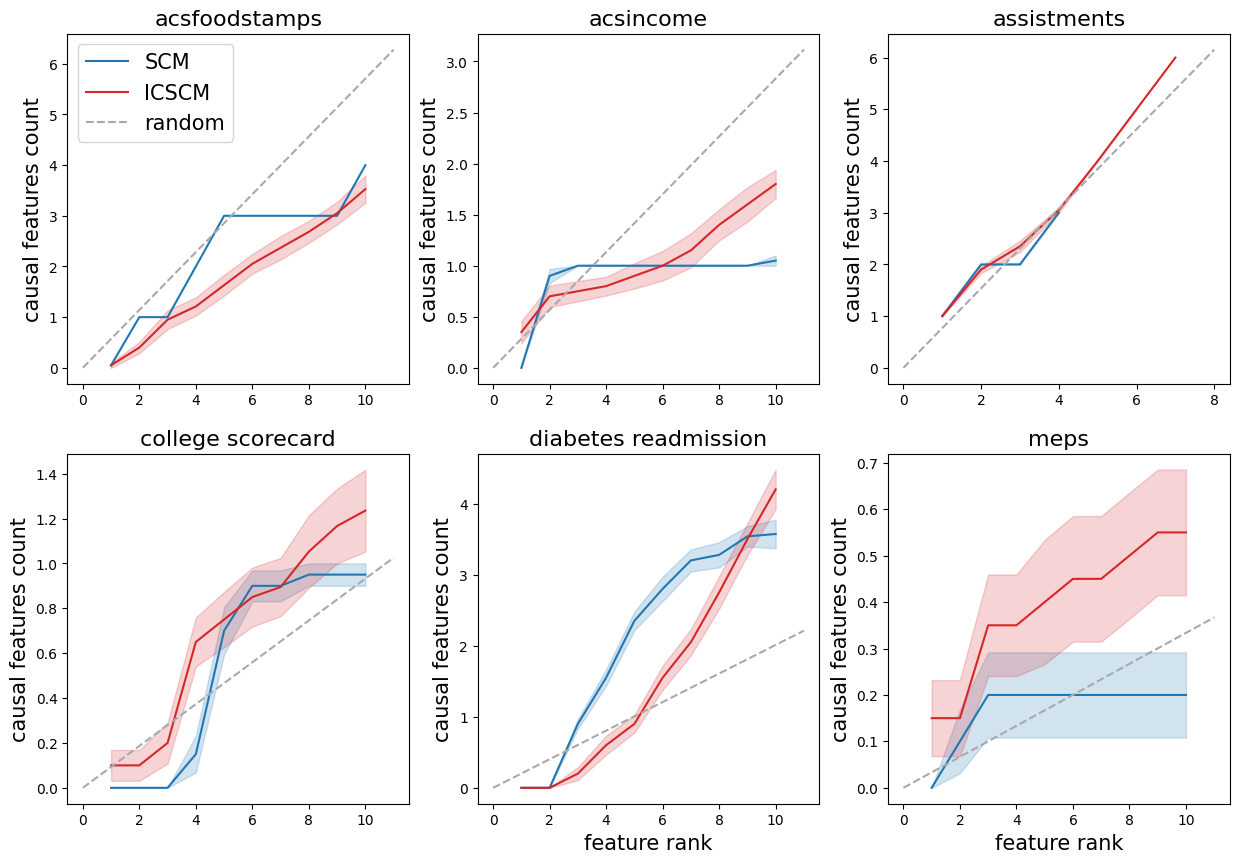

In [10]:
# clean figure for the paper

xlim = 12

#for errorbartype in ["sd", "se", "pi", "ci"]:
errorbartype, errorbarstr = "se", "standard error"
n_datasets = len(datasets_selection)
n_rows = n_datasets // 3 + n_datasets % 3
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
for i, dataset_name in enumerate(datasets_selection):
    if dataset_name not in datasets_selection:
        continue
    print(dataset_name)
    ax = axs[i // 3, i % 3]
    loc_df = big_df[big_df['dataset'] == dataset_name]
    loc_df = loc_df[loc_df['rank'] <= 12]
    hue_order = list(algos_color_palette.keys())
    sns.lineplot(data=loc_df, x='rank', y='causal count', hue='algo', ax=ax, palette=algos_color_palette, errorbar=errorbartype, hue_order=hue_order)
    # add the baseline
    baseline_dict = {}
    n = len(all_features_dict[dataset_name])
    m = len(causalfeatures_dict[dataset_name])
    for k in range(loc_df['rank'].max()+2):
        # probability of having samples i causal elements among the m causal elements (among the n elements) after k-1 samples
        expected_causal_count_with_random_pick = k*(m/n)
        baseline_dict[k] = expected_causal_count_with_random_pick
    ax.plot(list(baseline_dict.keys()), list(baseline_dict.values()), color='darkgrey', linestyle='dashed', label='random')
    clean_dataset_name = dataset_name.split('_envdefinition')[0]
    clean_dataset_name = clean_dataset_name.replace('_', ' ')
    ax.set_title(clean_dataset_name, fontsize=16)
    if i == 0:
        ax.legend(title='', loc='upper left', fontsize=15)
    else:
        ax.legend().remove()
    #ax.set_ylim(0, max_causalfeatures+0.5)
    if i<n_datasets-2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('feature rank', fontsize=15)
    ax.set_ylabel('causal features count', fontsize=15)
    #ax.set_xlim(0, 10.3)
    #ax.set_ylim(-0.1, dataset_to_ylim[dataset_name])
    # log scale on x axis
    #ax.set_xscale('log')
# more vertical space between subplots
plt.savefig('figures/figure4.pdf', bbox_inches='tight')
plt.show()